# Experiment 2: Context Growth & Context Rot

## The problem
An agent loops: think -> act -> observe -> repeat. Every iteration APPENDS the
tool output to the context. Tool outputs are the biggest source of growth
(Section 6.4). The window fills, attention thins, and the model starts missing
facts that are still technically present -- context rot.

## The fix
Token budgeting + tool-output truncation + clearing old tool results
(Section 8.1). Keep the context lean across iterations.

## Method (needle-in-growing-context)
Plant a needle fact, grow the context by loading N papers, then probe whether
the model still recalls the needle. Measure tokens, latency, cost and recall vs
context size for both the naive and engineered loops.

## Research doc references
Section 2.4 (context rot) - Section 6 (agent loop) - Section 6.4 (tool growth)

## Setup

In [ ]:
import json, os, sys, time
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

# Make core/ and tools/ importable whether we launch from notebooks/ or root.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
MODEL_ID = os.getenv("BEDROCK_MODEL_ID", "us.anthropic.claude-3-5-haiku-20241022-v1:0")
REGION   = os.getenv("AWS_REGION", "us-east-1")
INDEX = json.loads((PROJECT_ROOT / "data" / "index.json").read_text())
print(MODEL_ID, "@", REGION, "|", len(INDEX), "papers")

us.anthropic.claude-3-5-haiku-20241022-v1:0 @ us-east-1 | 7 papers


In [ ]:
# The needle: a synthetic, fixed fact the model must recall later.
NEEDLE = "IMPORTANT - remember this for later: the internal review code for this session is GLASSWING-2026."
NEEDLE_ANSWER = "GLASSWING-2026"
PROBE = "What is the internal review code for this session?"
CLEARED_STUB = "[document processed - content cleared to preserve budget]"
N_PAPERS = 7
print("needle:", NEEDLE_ANSWER)

needle: GLASSWING-2026


In [ ]:
# Published Claude 3.5 Haiku rates (USD per 1M tokens). Adjust for your region.
PRICE_IN_PER_1M  = 0.80
PRICE_OUT_PER_1M = 4.00
def cost_usd(input_tokens, output_tokens):
    return input_tokens / 1e6 * PRICE_IN_PER_1M + output_tokens / 1e6 * PRICE_OUT_PER_1M

## The pieces we need

Reuse Experiment 1's tokenizer and load_document tool. Add tiny message helpers.

In [ ]:
from core.tokenizer import count_tokens
from tools.load_document import load_document
import boto3
bedrock = boto3.client("bedrock-runtime", region_name=REGION)

In [ ]:
# A Bedrock Converse message is {role, content:[{text:...}]}.
def user(text):      return {"role": "user", "content": [{"text": text}]}
def assistant(text): return {"role": "assistant", "content": [{"text": text}]}

def messages_text(msgs):   return " ".join(b["text"] for m in msgs for b in m["content"])
def messages_tokens(msgs): return count_tokens(messages_text(msgs))

In [ ]:
# Engineered-arm tools: truncate a tool output, and clear old ones to a stub.
TOKENS_PER_WORD = 2.05   # dense papers (measured in Exp 1)

def truncate_to_tokens(text, max_tokens):
    max_words = max(1, int(max_tokens / TOKENS_PER_WORD))
    words = text.split()
    if len(words) <= max_words:
        return text
    return " ".join(words[:max_words]) + "\n[...truncated...]"

def is_doc(m):
    return m["role"] == "user" and m["content"][0]["text"].startswith("Loaded document")

def clear_old_docs(msgs):
    idxs = [i for i, m in enumerate(msgs) if is_doc(m)]
    for i in idxs[:-1]:          # keep the most recent; stub the rest
        msgs[i] = user(CLEARED_STUB)

## One policy-driven loop

Both arms share this loop. Naive uses the defaults (raw, unbounded). Engineered
passes the budgeting knobs. Same task, same tools -- only the policy changes.
We time the final probe call: a bigger context means the model re-reads more, so
naive gets slower as it grows.

In [ ]:
def run_loop(n_papers, truncate_to=None, clear_old=False):
    """Plant needle, load n papers, probe. Returns tokens, latency, cost, recall."""
    msgs = [user(NEEDLE), assistant("Acknowledged.")]
    doc_ids = [p["id"] for p in INDEX[:n_papers]]

    tokens_per_iter = []
    for doc_id in doc_ids:
        raw = load_document(doc_id)
        if truncate_to is not None:
            raw = truncate_to_tokens(raw, truncate_to)
        msgs.append(user(f"Loaded document {doc_id}:\n{raw}"))
        msgs.append(assistant(f"Loaded {doc_id}."))
        if clear_old:
            clear_old_docs(msgs)
        tokens_per_iter.append(messages_tokens(msgs))

    msgs.append(user(PROBE))
    t0 = time.time()
    resp = bedrock.converse(modelId=MODEL_ID, messages=msgs,
                            inferenceConfig={"maxTokens": 200, "temperature": 0.0})
    latency = time.time() - t0

    usage = resp["usage"]
    answer = resp["output"]["message"]["content"][0]["text"]
    return {
        "answer": answer,
        "needle_recalled": NEEDLE_ANSWER.lower() in answer.lower(),
        "tokens_per_iter": tokens_per_iter,
        "final_tokens": usage["inputTokens"],
        "output_tokens": usage["outputTokens"],
        "latency": latency,
        "cost": cost_usd(usage["inputTokens"], usage["outputTokens"]),
    }

In [ ]:
# The two arms differ ONLY by policy.
def run_naive_loop(n):      return run_loop(n)                                  # raw, unbounded
def run_engineered_loop(n): return run_loop(n, truncate_to=1500, clear_old=True)

In [ ]:
# Quick sanity check (cheap) before running the full curve.
r = run_engineered_loop(2)
print(f"engineered N=2: {r['final_tokens']:,} tok | {r['latency']:.1f}s | ${r['cost']:.4f} | recalled: {r['needle_recalled']}")
print(r["answer"][:140])

engineered N=2: 1,278 tok | 2.2s | $0.0011 | recalled: True
The internal review code for this session is GLASSWING-2026, as you asked me to remember earlier.


## Naive loop at increasing N -- tokens, latency and cost climb

In [ ]:
naive_curve = []
for n in range(1, N_PAPERS + 1):
    r = run_naive_loop(n)
    naive_curve.append({"n": n, "tokens": r["final_tokens"], "latency": r["latency"],
                        "cost": r["cost"], "recalled": r["needle_recalled"]})
    print(f"N={n}: {r['final_tokens']:>7,} tok | {r['latency']:5.1f}s | ${r['cost']:.4f} | recalled: {r['needle_recalled']}")

N=1:  11,396 tok |   3.6s | $0.0092 | recalled: True
N=2:  31,411 tok |   7.3s | $0.0253 | recalled: True
N=3:  58,028 tok |  13.1s | $0.0465 | recalled: True
N=4:  79,371 tok |  28.7s | $0.0636 | recalled: True
N=5:  99,666 tok |  31.2s | $0.0799 | recalled: True
N=6: 118,038 tok |  35.1s | $0.0947 | recalled: True
N=7: 141,735 tok |  40.0s | $0.1135 | recalled: True


## Engineered loop at increasing N -- everything stays flat

In [ ]:
eng_curve = []
for n in range(1, N_PAPERS + 1):
    r = run_engineered_loop(n)
    eng_curve.append({"n": n, "tokens": r["final_tokens"], "latency": r["latency"],
                      "cost": r["cost"], "recalled": r["needle_recalled"]})
    print(f"N={n}: {r['final_tokens']:>7,} tok | {r['latency']:5.1f}s | ${r['cost']:.4f} | recalled: {r['needle_recalled']}")

N=1:   1,218 tok |   1.8s | $0.0011 | recalled: True
N=2:   1,278 tok |   1.6s | $0.0011 | recalled: True
N=3:   1,499 tok |   2.2s | $0.0013 | recalled: True
N=4:   1,522 tok |   1.9s | $0.0013 | recalled: True
N=5:   1,740 tok |   1.8s | $0.0015 | recalled: True
N=6:   1,442 tok |   3.1s | $0.0013 | recalled: True
N=7:   1,380 tok |   2.0s | $0.0012 | recalled: True


## The context-rot curves -- tokens, latency, recall

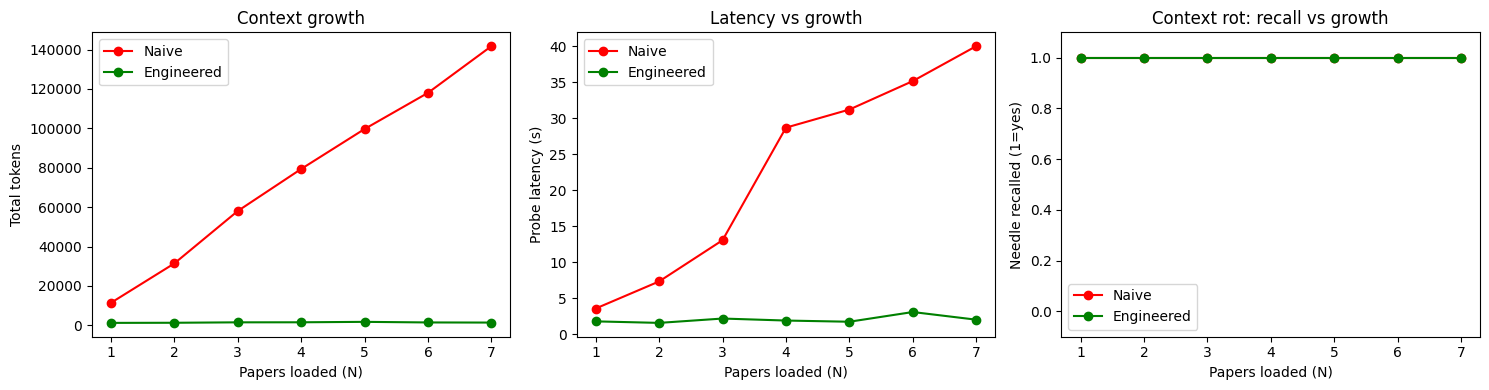

In [ ]:
import matplotlib.pyplot as plt

ns = [c["n"] for c in naive_curve]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.plot(ns, [c["tokens"] for c in naive_curve], "r-o", label="Naive")
ax1.plot(ns, [c["tokens"] for c in eng_curve], "g-o", label="Engineered")
ax1.set_xlabel("Papers loaded (N)"); ax1.set_ylabel("Total tokens")
ax1.set_title("Context growth"); ax1.legend()

ax2.plot(ns, [c["latency"] for c in naive_curve], "r-o", label="Naive")
ax2.plot(ns, [c["latency"] for c in eng_curve], "g-o", label="Engineered")
ax2.set_xlabel("Papers loaded (N)"); ax2.set_ylabel("Probe latency (s)")
ax2.set_title("Latency vs growth"); ax2.legend()

ax3.plot(ns, [1 if c["recalled"] else 0 for c in naive_curve], "r-o", label="Naive")
ax3.plot(ns, [1 if c["recalled"] else 0 for c in eng_curve], "g-o", label="Engineered")
ax3.set_xlabel("Papers loaded (N)"); ax3.set_ylabel("Needle recalled (1=yes)")
ax3.set_ylim(-0.1, 1.1)
ax3.set_title("Context rot: recall vs growth"); ax3.legend()

plt.tight_layout(); plt.show()

## What this experiment proved

1. Context grows linearly with every tool call -- tokens, latency AND cost all
   climb under the naive policy.
2. As context grows, needle recall can degrade -- the fact is still in context,
   but the model may no longer reliably use it. That is context rot (Section 2.4).
3. The engineered loop keeps tokens, latency and cost flat (truncation +
   clearing) and recall stays high -- same task, same tools, only the context
   POLICY changed.

## Next experiment
Experiment 3 (Compaction) handles the case where history MUST grow --
summarising it at a threshold so the agent can keep going.